### **Начало проекта**

**Введение в проект**


Вам предстоит сделать предварительный анализ тарифов на небольшой выборке клиентов. В вашем распоряжении данные 500 пользователей «Мегалайна»: кто они, откуда, каким тарифом пользуются, сколько звонков и сообщений каждый отправил за 2018 год. Нужно проанализировать поведение клиентов и сделать вывод — какой тариф лучше.


#### **Шаг 1. Открываем файлы с данными и изучаем общую информацию**

In [2]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np
import os
from scipy import stats as st
from sklearn import datasets
import seaborn as sns
import altair as alt

In [3]:
pth1 = '/Users/ikashkovskiy/Desktop/YANDEX P/data/megaline/calls.csv' 
pth2 = '/datasets/calls.csv'

if os.path.exists(pth1):
    df_calls = pd.read_csv(pth1)
elif os.path.exists(pth2):
    df_calls = pd.read_csv(pth2)
else:
    print('Something is wrong')

In [4]:
pth3 = '/Users/ikashkovskiy/Desktop/YANDEX P/data/megaline/internet.csv' 
pth4 = '/datasets/internet.csv'

if os.path.exists(pth3):
    df_internet = pd.read_csv(pth3)
elif os.path.exists(pth4):
    df_internet = pd.read_csv(pth4) 
else:
    print('Something is wrong')

In [5]:
pth5 = '/Users/ikashkovskiy/Desktop/YANDEX P/data/megaline/messages.csv' 
pth6 = '/datasets/calls.csv'

if os.path.exists(pth5):
    df_messages = pd.read_csv(pth5)
elif os.path.exists(pth6):
    df_messages = pd.read_csv(pth6)  
else:
    print('Something is wrong')

In [6]:
pth7 = '/Users/ikashkovskiy/Desktop/YANDEX P/data/megaline/tariffs.csv' 
pth8 = '/datasets/tarrifs.csv'

if os.path.exists(pth7):
    df_tariffs = pd.read_csv(pth7)
elif os.path.exists(pth8):
    df_tariffs = pd.read_csv(pth8) 
else:
    print('Something is wrong')

In [7]:
pth9 = '/Users/ikashkovskiy/Desktop/YANDEX P/data/megaline/users.csv' 
pth10 = '/datasets/tarrifs.csv'

if os.path.exists(pth7):
    df_users = pd.read_csv(pth9)
elif os.path.exists(pth8):
    df_users = pd.read_csv(pth10) 
else:
    print('Something is wrong')

In [8]:
#df_users.info()

In [9]:
#df_messages.info()

In [10]:
#df_internet.info()

In [11]:
#df_calls.info()

In [12]:
#df_tariffs.info()

**Данные получены, нужно изменить тип данных дат и удалить лишний столбец в df_internet**

### **Шаг 2. Подготовка данных**

In [13]:
df_users['reg_date'] = pd.to_datetime(df_users['reg_date'], format='%Y-%m-%d')

In [14]:
df_users['churn_date'] = pd.to_datetime(df_users['churn_date'], format='%Y-%m-%d')

In [15]:
#исправил тип данных столбцов с датами на datetime64

In [16]:
#добавляем столбец с месяцем
df_messages['message_date'] = pd.to_datetime(df_messages['message_date'], format='%Y-%m-%d')
df_messages['month'] = df_messages['message_date'].dt.month

In [17]:
#добавляем столбец с месяцем
df_internet['session_date'] = pd.to_datetime(df_internet['session_date'], format='%Y-%m-%d')
df_internet['month'] = df_internet['session_date'].dt.month

In [18]:
#удаляем лишний столбец
df_internet = df_internet.drop('Unnamed: 0', axis=1)
#df_internet.info()

In [19]:
#добавляем столбец с месяцем
df_calls['call_date'] = pd.to_datetime(df_calls['call_date'], format='%Y-%m-%d')
df_calls['month'] = df_calls['call_date'].dt.month

In [20]:
#сумма звонков и минут по месяцам для каждого пользователя
df_calls_sum = df_calls.pivot_table(index=['user_id', 'month'],aggfunc={'call_date':'count', 'duration':sum})
df_calls_sum.columns = ['calls_sum', 'minutes_sum']
df_calls_sum.head(10)

calls_sum  minutes_sum
user_id month                        
1000    5             22       150.06
        6             43       158.90
        7             47       318.80
        8             52       389.87
        9             58       440.14
        10            57       328.45
        11            43       319.04
        12            46       312.98
1001    11            59       408.12
        12            63       391.34

In [21]:
#округляем минуты
df_calls_sum['minutes_sum'] = np.ceil(df_calls_sum['minutes_sum'])

In [22]:
#сумма мб и сессий по месяцам для каждого пользователя
df_internet_sum = df_internet.pivot_table(index=['user_id', 'month'],aggfunc={'session_date':'count', 'mb_used':sum})
df_internet_sum.columns = ['mb_used_sum', 'session_sum']
#df_internet_sum.head(10)

In [23]:
#сумма сообщений по месяцам для каждого пользователя
df_messages_sum = df_messages.pivot_table(index=['user_id', 'month'], aggfunc={'id':'count'})
df_messages_sum.columns = ['message_sum']
#df_messages_sum.head(10)

**Исправил строки с датами на правильный тип данных, удалил не нужный столбец, округлил минуты, выделил столбец суммами минут, сообщений и траффика по месяцам**

In [24]:
df_sum = df_messages_sum.join([df_internet_sum, df_calls_sum]).reset_index(level='month')

In [25]:
df_sum = df_sum.drop('session_sum', axis=1)

In [26]:
df_sum.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2717 entries, 1000 to 1499
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   month        2717 non-null   int64  
 1   message_sum  2717 non-null   float64
 2   mb_used_sum  2706 non-null   float64
 3   calls_sum    2678 non-null   float64
 4   minutes_sum  2678 non-null   float64
dtypes: float64(4), int64(1)
memory usage: 127.4 KB


In [27]:
df = df_users.merge(df_sum, on='user_id', how='right')

In [28]:
df_month_income = df.drop(['age', 'churn_date', 'first_name', 'last_name', 'reg_date'], axis='columns')
#убираем лишние столбцы

In [29]:
df_month_income['mb_used_sum'] = df_month_income['mb_used_sum'].fillna(0)
df_month_income['calls_sum'] = df_month_income['calls_sum'].fillna(0)
df_month_income['minutes_sum'] = df_month_income['minutes_sum'].fillna(0)
#заменяем пропуски нулями

In [30]:
df_month_income['mb_used_sum'] = df_month_income['mb_used_sum'] / 1024
#меняем мб на гб

In [31]:
df_month_income['mb_used_sum'] = np.ceil(df_month_income['mb_used_sum'])
#округляем в большую сторону по условиям тарифов

In [32]:
df_month_income = df_month_income.rename(columns={'mb_used_sum' : 'gb_used_sum'})

In [33]:
#добавим тарифы
df_tariffs = df_tariffs.rename(columns={'tariff_name' : 'tariff'})

In [34]:
df_month_income = df_month_income.merge(df_tariffs, on='tariff')

In [35]:
df_month_income = df_month_income.rename(columns={'mb_per_month_included' : 'gb_per_month_included'})

In [36]:
df_month_income['gb_per_month_included'] = df_month_income['gb_per_month_included'] / 1024
#меняем мб на гб

In [37]:
df_month_income = df_month_income.astype({'message_sum': np.int64, 'gb_used_sum': np.int64, 
                'calls_sum': np.int64, 'minutes_sum': np.int64, 'gb_per_month_included': np.int64})

In [38]:
df_month_income

,user_id,city,tariff,month,message_sum,gb_used_sum,calls_sum,minutes_sum,messages_included,gb_per_month_included,minutes_included,rub_monthly_fee,rub_per_gb,rub_per_message,rub_per_minute
0,1000,Краснодар,ultra,5,22,3,22,151,1000,30,3000,1950,150,1,1
1,1000,Краснодар,ultra,6,60,23,43,159,1000,30,3000,1950,150,1,1
2,1000,Краснодар,ultra,7,75,14,47,319,1000,30,3000,1950,150,1,1
3,1000,Краснодар,ultra,8,81,14,52,390,1000,30,3000,1950,150,1,1
4,1000,Краснодар,ultra,9,57,15,58,441,1000,30,3000,1950,150,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2712,1498,Владикавказ,smart,10,42,21,41,233,50,15,500,550,200,3,3
2713,1499,Пермь,smart,9,11,2,9,65,50,15,500,550,200,3,3
2714,1499,Пермь,smart,10,48,18,68,430,50,15,500,550,200,3,3
2715,1499,Пермь,smart,11,59,18,74,577,50,15,500,550,200,3,3


**Таблица с помесячной выручкой с каждого пользователя**

In [39]:
#функция для подсчетов суммы к оплате каждый месяц для клиентов 
#с учетом перерасходов услуг сверх включенных в тариф
def income_per_month(row):
    
    overlimit_min = 0
    overlimit_message = 0
    overlimit_gb = 0
    tarrif_cost = row['rub_monthly_fee']
    message_sum = row['message_sum']
    gb_used_sum = row['gb_used_sum']
    minutes_sum = row['minutes_sum']
    messages_included = row['messages_included']
    gb_per_month_included = row['gb_per_month_included']
    minutes_included = row['minutes_included']
    rub_monthly_fee = row['rub_monthly_fee']
    rub_per_gb = row['rub_per_gb']
    rub_per_message = row['rub_per_message']
    rub_per_minute = row['rub_per_minute']
    
    if message_sum > messages_included:
        overlimit_message += (message_sum - messages_included) * rub_per_message
    if gb_used_sum > gb_per_month_included:
        overlimit_gb += (gb_used_sum - gb_per_month_included) * rub_per_gb
    if minutes_sum > minutes_included:
        overlimit_message += (minutes_sum - minutes_included) * rub_per_minute
    return overlimit_message + overlimit_min + overlimit_gb + tarrif_cost

df_month_income['total_income'] = df_month_income.apply(income_per_month, axis=1)
#добавляем столбец в таблицу с итогами

In [40]:
#проверяем
#df_month_income

### **Шаг 3. Проанализируем данные Опишем поведение клиентов оператора, исходя из выборки**

In [41]:
#Таблица с суммами использованных и оплаченных услуг по месяцам для каждого тарифа
df_month_income_mean = (df_month_income
                .pivot_table(index=['tariff', 'month'],
                             values=['message_sum', 'calls_sum', 'gb_used_sum', 'minutes_sum', 'total_income'],
                             aggfunc = np.mean))

df_month_income_mean = df_month_income_mean.reset_index(level='month')
df_month_income_mean

,month,calls_sum,gb_used_sum,message_sum,minutes_sum,total_income
tariff,,,,,,
smart,1,28.258065,8.870968,20.000000,199.967742,729.225806
smart,2,42.380000,12.160000,27.940000,295.720000,805.060000
smart,3,54.652174,14.782609,35.550725,371.231884,1093.550725
smart,4,53.312500,13.812500,35.864583,360.468750,949.770833
smart,5,56.754098,16.245902,39.032787,377.377049,1193.934426
smart,6,55.598592,15.922535,38.577465,374.429577,1178.154930
smart,7,56.678161,15.954023,38.988506,386.913793,1196.603448
smart,8,59.588235,16.862745,38.750000,402.151961,1318.514706
smart,9,59.094170,16.457399,39.219731,403.820628,1223.708520


**При усредненном анализе используемых услуг в течении года по месяцам:**

*Использую среднее, так как на сумме показателей по месяцам на так очевидны различия между тарифами из-за различия лимитов*

*На тарифе СМАРТ*

- заметен рост колличества сообщений, минут звонков, количества звонков, траффика и стоимости услуг в течении года от января к декабрю. Можно сделать вывод, о том что в январе случается спад использования услуг и падение выручки почти на 50% по сравнению с декабрем.

*На тарифе УЛЬТРА*

- явного увеличения использования услуг не наблюдается. Так же и спада в начале года не наблюдается.

In [42]:
df_month_income_mean = df_month_income.pivot_table(index=['tariff'],aggfunc={'message_sum':'mean',
                                                                             'calls_sum':'mean',
                                                                            'gb_used_sum':'mean',
                                                                            'minutes_sum':'mean',
                                                                            'user_id':'count',
                                                                            'total_income':'mean'})
df_month_income_mean

#видно, что в среднем на тарифе "смарт" пользователи не превышают лимиты и платят меньше, 
#при том что стоимость абонентской платы выше почти в 4 раза
#а на тарифе "ультра" превышают и платят за это, в среднем больше, из-за высокой стоимости услуг сверх лимита

,calls_sum,gb_used_sum,message_sum,minutes_sum,total_income,user_id
tariff,,,,,,
smart,58.659209,16.353278,38.716441,396.433403,1256.617586,1922
ultra,73.906918,19.397484,61.161006,500.310692,2047.735849,795


In [43]:
df_ultra = df_month_income.query('tariff == "ultra"')
df_ultra = df_ultra.drop(['month',
                          'messages_included',
                          'gb_per_month_included',
                          'minutes_included',
                          'rub_monthly_fee',
                          'rub_per_gb','rub_per_message','rub_per_minute'], axis='columns')
#df_ultra.describe()

In [44]:
df_smart = df_month_income.query('tariff == "smart"')
df_smart = df_smart.drop(['month',
                          'messages_included',
                          'gb_per_month_included',
                          'minutes_included',
                          'rub_monthly_fee',
                         'rub_per_gb','rub_per_message','rub_per_minute'], axis='columns')
#df_smart.describe()

In [45]:
df_month_income_var = df_month_income.pivot_table(index=['tariff'],aggfunc={'message_sum':np.var,
                                                                             'calls_sum':np.var,
                                                                            'gb_used_sum':np.var,
                                                                            'minutes_sum':np.var,
                                                                            'user_id':'count',
                                                                            'total_income':np.var})
df_month_income_var

#дисперсия

,calls_sum,gb_used_sum,message_sum,minutes_sum,total_income,user_id
tariff,,,,,,
smart,663.060792,32.215057,717.594201,31971.475261,646755.118129,1922
ultra,2020.842710,91.005535,2109.659183,94180.305112,108036.428877,795


In [46]:
df_month_income_std = df_month_income.pivot_table(index=['tariff'],aggfunc={'message_sum':np.std,
                                                                             'calls_sum':np.std,
                                                                            'gb_used_sum':np.std,
                                                                            'minutes_sum':np.std,
                                                                            'user_id':'count',
                                                                            'total_income':np.std})
df_month_income_std

#стандартное отклонение

,calls_sum,gb_used_sum,message_sum,minutes_sum,total_income,user_id
tariff,,,,,,
smart,25.749967,5.675831,26.787949,178.805691,804.210867,1922
ultra,44.953784,9.539682,45.931026,306.888099,328.688955,795


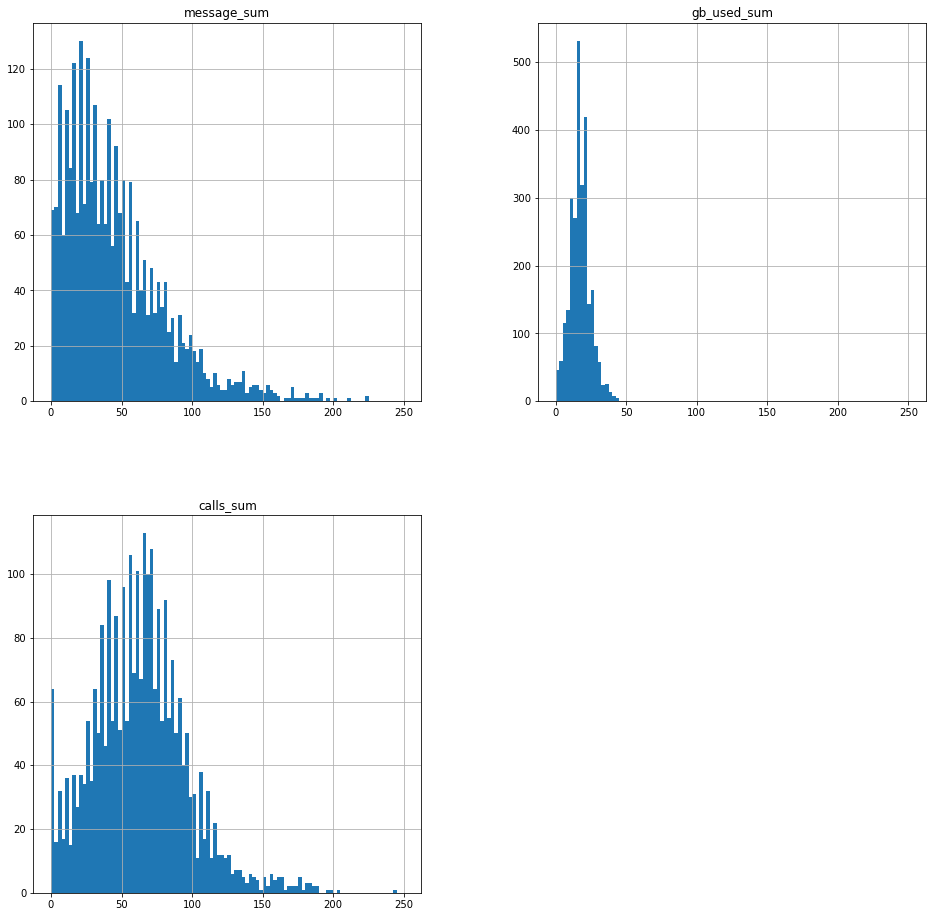

In [47]:
df_month_income_hist = df_month_income.drop(['user_id','month',
                          'messages_included',
                          'gb_per_month_included',
                          'minutes_included',
                          'rub_monthly_fee',
                         'rub_per_gb','rub_per_message','rub_per_minute', 'total_income', 'minutes_sum'], axis='columns')
df_month_income_hist.hist(bins=100,range=(0, 250), figsize=(16,16))
plt.show()

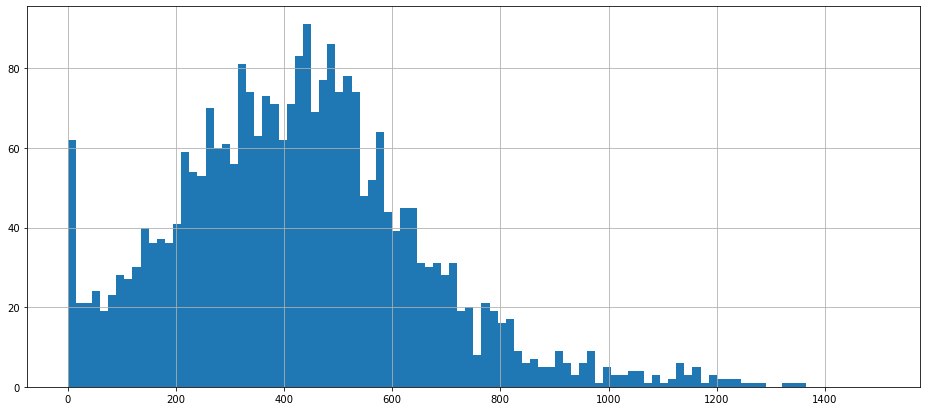

In [48]:
df_month_income['minutes_sum'].hist(bins=100,range=(0, 1500), figsize=(16,7))
plt.show()

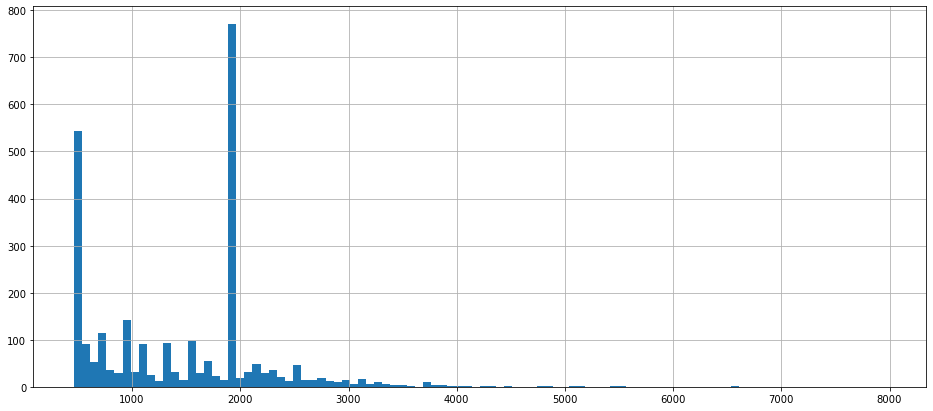

In [49]:
df_month_income['total_income'].hist( bins=100,
                                     range=(500, 8000),
                                     figsize=(16,7),
                                     align ='left')
plt.show()
#распределение выставленных сумм платежей за месяца
#заметны пики на 550 и 1950Р

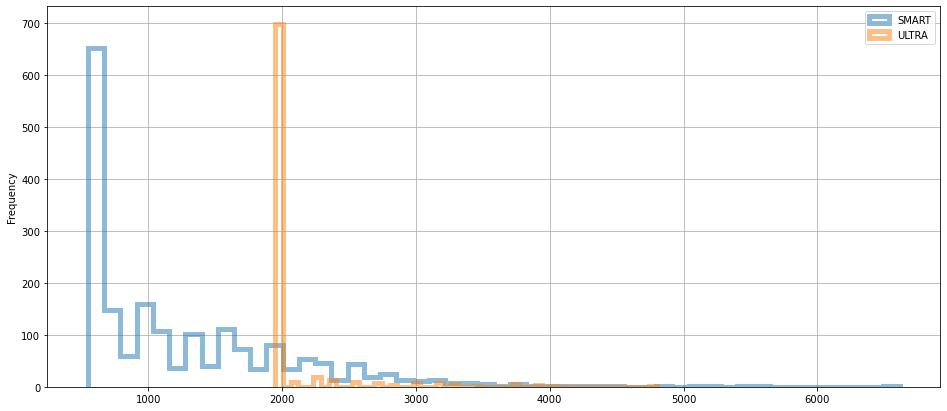

In [50]:
#сравнение по итоговой сумме к оплате по месяцая
ax = df_smart.plot(kind='hist', y='total_income', histtype='step', bins=50, 
                     linewidth=5, alpha=0.5, label='SMART')
df_ultra.plot(kind='hist', y='total_income', histtype='step', bins=50,
linewidth=5, alpha=0.5, label='ULTRA', ax=ax, grid=True, legend=True, figsize=(16,7))
plt.show()

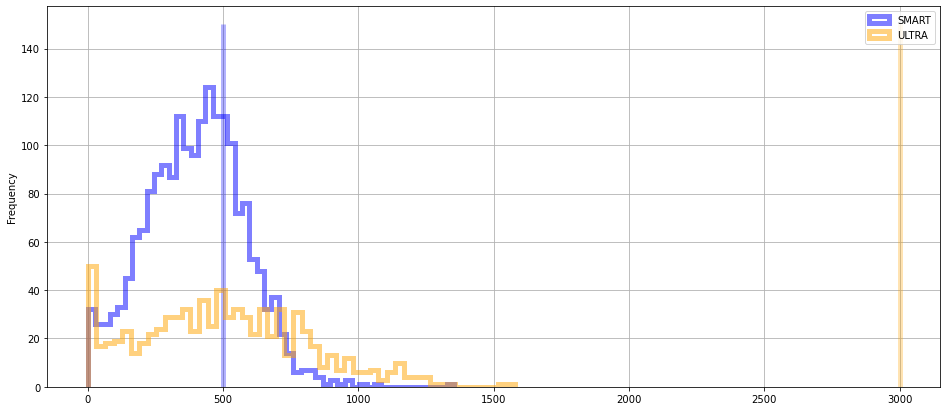

In [51]:
#сравнение по использованным минутам с лимитами
ax = df_smart.plot(kind='hist', y='minutes_sum', histtype='step', bins=50, 
                     linewidth=5, alpha=0.5,color='blue', label='SMART')

df_ultra.plot(kind='hist', y='minutes_sum', histtype='step', bins=50,
linewidth=5, alpha=0.5, label='ULTRA', ax=ax, grid=True, legend=True, color='orange', figsize=(16,7))

ax.vlines(500, 0, 150, color='blue', alpha=0.3, linewidth=5)
ax.vlines(3000, 0, 150, color='orange',alpha=0.3, linewidth=5)
plt.show()

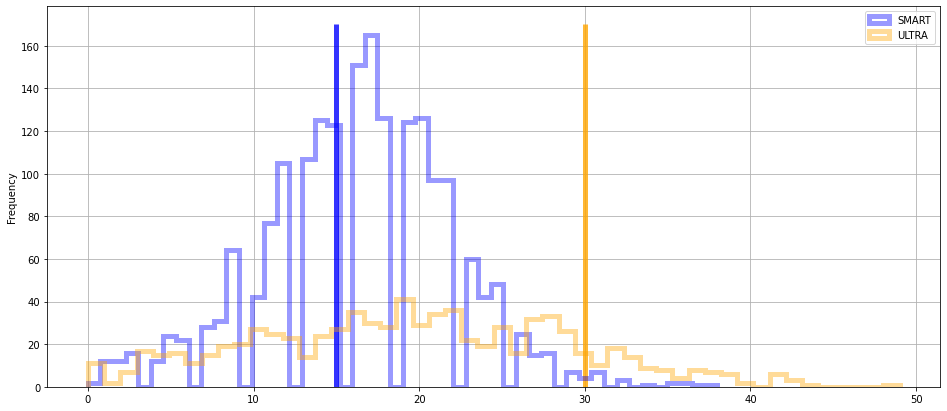

In [52]:
#сравнение по траффику с лимитами
ax = df_smart.plot(kind='hist', y='gb_used_sum', histtype='step', bins=50, 
                     linewidth=5, alpha=0.4, color='blue', label='SMART')

df_ultra.plot(kind='hist', y='gb_used_sum', histtype='step', bins=50,
linewidth=5, alpha=0.4, label='ULTRA', ax=ax, grid=True, legend=True, color='orange', figsize=(16,7))

ax.vlines(15, 0, 170, color='blue', alpha=0.8, linewidth=5)
ax.vlines(30, 0, 170, color='orange',alpha=0.8, linewidth=5)
plt.show()

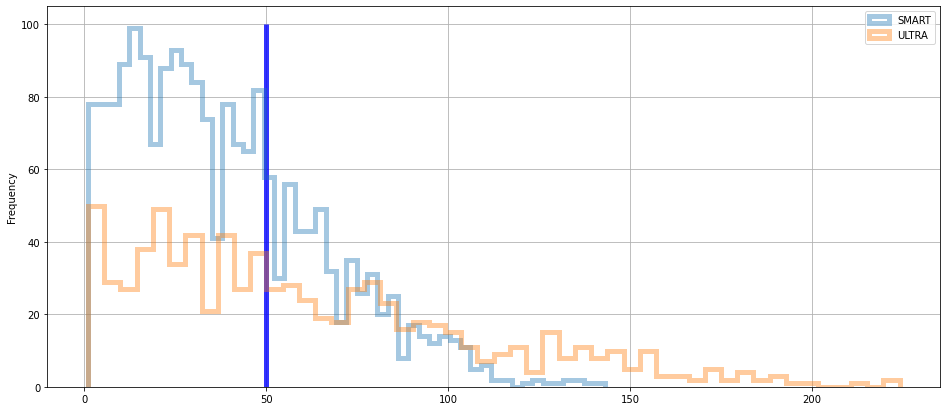

In [53]:
#сравнение по сообщениям с лимитами
ax = df_smart.plot(kind='hist', y='message_sum', histtype='step', bins=50, 
                     linewidth=5, alpha=0.4, label='SMART')

df_ultra.plot(kind='hist', y='message_sum', histtype='step', bins=50,
linewidth=5, alpha=0.4, label='ULTRA', ax=ax, grid=True, legend=True, figsize=(16,7))

ax.vlines(50, 0, 100, color='blue', alpha=0.8, linewidth=5)
#ax.vlines(1000, 0, 100, color='orange',alpha=0.8, linewidth=5) 
#не влезает в график

plt.show()

**Распределение по тарифу СМАРТ**

/Users/ikashkovskiy/opt/anaconda3/lib/python3.9/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


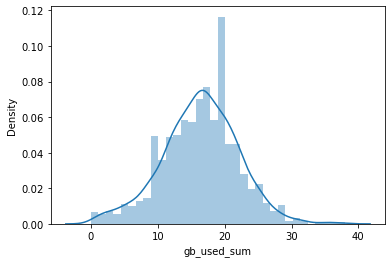

In [54]:
sns_plot = sns.distplot(df_smart['gb_used_sum'])
fig = sns_plot.get_figure()

/Users/ikashkovskiy/opt/anaconda3/lib/python3.9/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


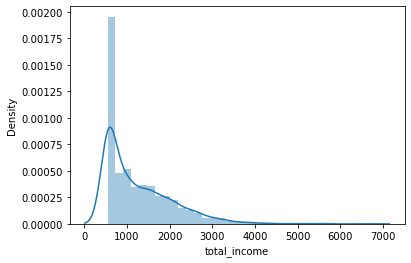

In [55]:
sns_plot = sns.distplot(df_smart['total_income'])
fig = sns_plot.get_figure()

/Users/ikashkovskiy/opt/anaconda3/lib/python3.9/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


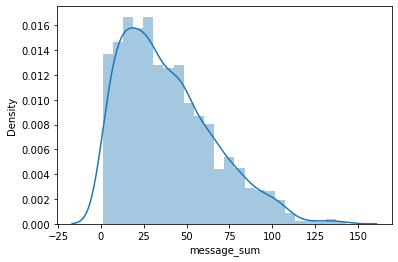

In [56]:
sns_plot = sns.distplot(df_smart['message_sum'])
fig = sns_plot.get_figure()

/Users/ikashkovskiy/opt/anaconda3/lib/python3.9/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


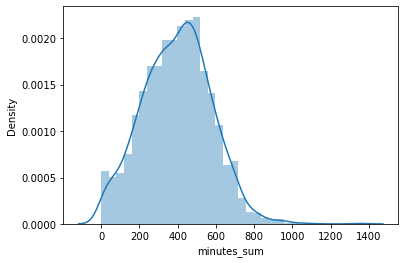

In [57]:
sns_plot = sns.distplot(df_smart['minutes_sum'])
fig = sns_plot.get_figure()

**Распределение по тарифу УЛЬТРА**

/Users/ikashkovskiy/opt/anaconda3/lib/python3.9/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


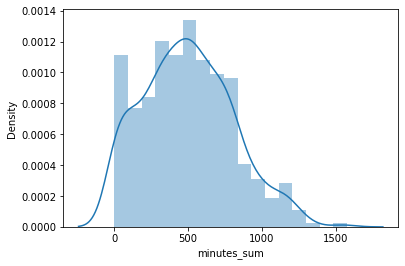

In [58]:
sns_plot = sns.distplot(df_ultra['minutes_sum'])
fig = sns_plot.get_figure()

/Users/ikashkovskiy/opt/anaconda3/lib/python3.9/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


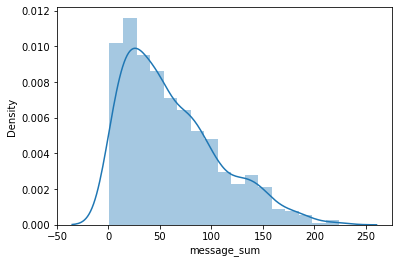

In [59]:
sns_plot = sns.distplot(df_ultra['message_sum'])
fig = sns_plot.get_figure()

/Users/ikashkovskiy/opt/anaconda3/lib/python3.9/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


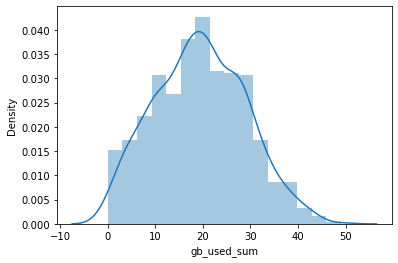

In [60]:
sns_plot = sns.distplot(df_ultra['gb_used_sum'])
fig = sns_plot.get_figure()

**Общее распределние - Нормальное**

/Users/ikashkovskiy/opt/anaconda3/lib/python3.9/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


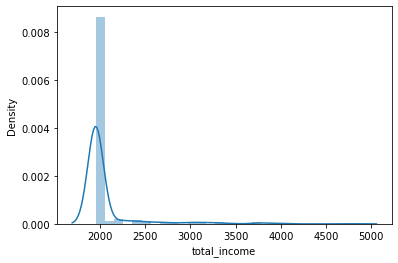

In [61]:
sns_plot = sns.distplot(df_ultra['total_income'])
fig = sns_plot.get_figure()

#### ВЫВОД ПО ШАГУ 3
**В выборке пользователей тарифа СМАРТ почти в 2.5 раза больше чем УЛЬТРА**
Но, по средним показателям можно сказать что, пользователи СМАРТ чаше в среднем превышают лимиты тарифа и платят за это в среднем сумму сопоставимую с 2 абонентскими платами - 1256руб.

С Тарифом УЛЬТРА ситуация другая, так как пользователи почти не превышают лимиты, то редко доплачивают за перерасход и в среднем платят в месяц 2047руб

Так же из анализа данных можно сделать выводы
 - Пользователи УЛЬТРА в среднем больше пользуются услугами связи
 - Пользователи обоих тарифов отправялют мало сообщений
 - Пользователи УЛЬТРА перерасходуют только траффик, его не хватает на обоих тарифах
 - Распределние близко к нормальному 



#### Шаг 4. Проверяем гипотезы
1. средняя выручка пользователей тарифов «Ультра» и «Смарт» различаются;
2. средняя выручка пользователей из Москвы отличается от выручки пользователей из других регионов.


#### Гипотеза 1
1. у качестве гипотезы Н0 выбераем утверждение, что средняя выручка пользователей тарифов «Ультра» и «Смарт» равны  в качестве гипотезы Н1 - утверждение, что средняя выручка пользователей тарифов «Ультра» и «Смарт» различаются.
- Пороговое значение стандартное.
2. Так как проверяем гипотезу о равенстве среднего двух неравных генеральных совокупностей, используем метод .ttest_ind() с условием equal_var=False

In [62]:
#Гипотеза 1. Средняя выручка пользователей тарифов «Ультра» и «Смарт» различаются 
# H0 - средние выручки равны, Н1 - средние выручки не равны

smart_ttest = df_smart['total_income']

ultra_ttest = df_ultra['total_income']

alpha = .05

results = st.ttest_ind(smart_ttest, ultra_ttest, equal_var=False)

print('p-значение:', results.pvalue)

if results.pvalue < alpha:
    print("Средняя выручка пользователей тарифов «Ультра» и «Смарт» различаются")
else:
    print("Средняя выручка пользователей тарифов «Ультра» и «Смарт» равны")

p-значение: 1.3447198086299033e-236
Средняя выручка пользователей тарифов «Ультра» и «Смарт» различаются


In [63]:
df_smart

,user_id,city,tariff,message_sum,gb_used_sum,calls_sum,minutes_sum,total_income
795,1002,Стерлитамак,smart,4,11,15,111,550
796,1002,Стерлитамак,smart,11,18,26,205,1150
797,1002,Стерлитамак,smart,13,20,42,270,1550
798,1002,Стерлитамак,smart,4,17,36,196,950
799,1002,Стерлитамак,smart,10,14,33,200,550
...,...,...,...,...,...,...,...,...
2712,1498,Владикавказ,smart,42,21,41,233,1750
2713,1499,Пермь,smart,11,2,9,65,550
2714,1499,Пермь,smart,48,18,68,430,1150
2715,1499,Пермь,smart,59,18,74,577,1408


#### Гипотеза 2
1. у качестве гипотезы Н0 выбераем утверждение, что средняя выручка пользователей из Москвы не отличается от выручки пользователей из других регионов,  в качестве гипотезы Н1 - утверждение, что средняя выручка пользователей из Москвы и пользователей из других регионов отличаются.
- Пороговое значение стандартное.
- Нужно создать таблицу с суммой всех платежей по каждому пользователю.
2. Так как проверяем гипотезу о равенстве среднего двух неравных генеральных совокупностей, используем метод .ttest_ind() с условием equal_var=False

In [121]:
#Гипотеза 1. Средняя выручка пользователей из Москвы отличается от выручки пользователей из других регионов.
# H0 - средние выручки равны, Н1 - средние выручки не равны

#таблица с суммой всех платежей по каждому пользователю 
df_users_income = df_month_income.pivot_table(
    index=['user_id', 'city'], 
    values='total_income',
    aggfunc=['sum']).sort_values(('user_id'),ascending=True)

moscow_ttest = df_users_income.query('city == "Москва"')

regions_ttest = df_users_income.query('city != "Москва"')

alpha = .05

results = st.ttest_ind(moscow_ttest, regions_ttest, equal_var=False)

print('p-значение:', results.pvalue)

if results.pvalue < alpha:
    print("Средняя выручка пользователей из Москвы и пользователей из других регионов отличаются")
else:
    print("Средняя выручка пользователей из Москвы не отличается от выручки пользователей из других регионов")

p-значение: [0.65868744]
Средняя выручка пользователей из Москвы не отличается от выручки пользователей из других регионов


### **Вывод**

Проведя анализ данных можно сделать следующие выводы:

- Пользователи УЛЬТРА в среднем больше платят за услуги связи, по сравнению с пользователями СМАРТА - пости на 1/3
- Пользователи УЛЬТРА практически не превышают лимитов тарифа, в отличие от пользователей СМАРТА 
- Средний расход клиентов обоих тарифов не зависит от их географии
- Пользователи СМАРТА нарашивают объем потребления услуг: колличества сообщений, минут звонков, количества звонков, траффика и соответственно стоимости с января по декабрь с резким падением на 50% в январе.
- Пользователи УЛЬТРА равномерно потребляют услуги, без резких калебаний в течении года.

*Основываясь на этих данных, можно сделать вывод о том что тариф УЛЬТРА более выгоден для компании - приносит стабильный доход, в среднем больший чем от клиентов на тарифе СМАРТ, даже с учетом роста выручки к концу года.*

*Но для клиентов более оптимальный тариф - СМАРТ, так как позволяет пользоваться услугами более гибко и экономить на услугах связи в месяцы, когда не нужно совершать много звонков или пользоватьсч интернетом.*